In [15]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    matthews_corrcoef, f1_score, roc_auc_score,
    precision_recall_fscore_support
)
from sklearn.svm import LinearSVC
from sklearn.metrics import make_scorer

from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer

from scipy.stats import friedmanchisquare, wilcoxon
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.stats import randint, uniform, loguniform
import matplotlib.pyplot as plt

In [16]:
from google.colab import drive
drive.mount('/content/gdrive')
import os

gdrive_root = "/content/gdrive/MyDrive/kidney_xgb_comparison"  # change if you want
os.makedirs(gdrive_root, exist_ok=True)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [25]:

path = f"RCC_{1}yr_mortality_dataset.csv"  # adjust if needed
df = pd.read_csv(path)
df['ICD-O-3 Hist/behav'].unique()
# df['Combined Summary Stage with Expanded Regional Codes (2004+)'].unique()

array(['8317/3: Renal cell carcinoma, chromophobe type',
       '8000/3: Neoplasm, malignant', '8312/3: Renal cell carcinoma',
       '8310/3: Clear cell adenocarcinoma, NOS',
       '8260/3: Papillary adenocarcinoma, NOS',
       '8071/3: Squamous cell carcinoma, keratinizing, NOS',
       '8323/3: Mixed cell adenocarcinoma',
       '8070/3: Squamous cell carcinoma, NOS',
       '8318/3: Renal cell carcinoma, sarcomatoid',
       '8510/3: Medullary carcinoma, NOS', '8010/3: Carcinoma, NOS',
       '8255/3: Adenocarcinoma with mixed subtypes',
       '8140/3: Adenocarcinoma, NOS',
       '8316/3: Cyst-associated renal cell carcinoma',
       '8311/3: Hereditary leiomyomatosis and RCC (HRCC)-associated RCC',
       '8123/3: Basaloid carcinoma',
       '8033/3: Pseudosarcomatous carcinoma',
       '8032/3: Spindle cell carcinoma, NOS',
       '8480/3: Mucinous adenocarcinoma',
       '8120/3: Transitional cell carcinoma, NOS',
       '8013/3: Large cell neuroendocrine carcinoma',
       

In [ ]:
# =====================
# 1. Load data
# =====================
years = [1,2,3,4]
path = f"RCC_{year}yr_mortality_dataset.csv"  # adjust if needed
df = pd.read_csv(path)

# Get the name of the last column
last_column_name = df.columns[-1]


X = df.drop(columns=[last_column_name])
y = df[last_column_name]

# =====================
# 2. Feature types
# =====================
numeric_features = [
    "Total number of in situ/malignant tumors for patient",
    "Total number of benign/borderline tumors for patient",
]

categorical_features = [c for c in X.columns if c not in numeric_features]


NameError: name 'year' is not defined

In [ ]:
# path to your already computed XGB results
xgb_csv_path = f"/content/gdrive/MyDrive/AML/xgb_binary_artifacts_year{year}/xgb_binary_cv_folds_metrics.csv"   # change if needed

xgb_df = pd.read_csv(xgb_csv_path)

# if the file contains only XGB rows:
xgb_mcc = xgb_df["MCC"].to_numpy()
xgb_f1  = xgb_df["F1"].to_numpy()
xgb_auc = xgb_df["AUC"].to_numpy()

# initialise results dict with XGB already filled
results = {
    "XGB": {
        "MCC": xgb_mcc,
        "F1":  xgb_f1,
        "AUC": xgb_auc,
    }
}

n_outer_folds = len(xgb_mcc)  # we will reuse this for other models
print("Loaded XGB folds:", n_outer_folds)

Loaded XGB folds: 10


In [ ]:
# =========================================================
# 2. preprocessing
# =========================================================
numeric_features = [
    "Total number of in situ/malignant tumors for patient",
    "Total number of benign/borderline tumors for patient",
]
# Numeric: scale
numeric_filter = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
    ]
)

# Categorical: one-hot
categorical_filter = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_filter, numeric_features),
        ("cat", categorical_filter, categorical_features),
    ]
)

NameError: name 'categorical_features' is not defined

In [ ]:
# # SVM Linear SVM
svm_base = LinearSVC(random_state=42)
param_svm = {
    "clf__C": loguniform(1e-3, 1e3),
    "clf__penalty": ["l2"],
    "clf__loss": ["hinge", "squared_hinge"],
}

# Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)

param_dt = {
    "clf__max_depth": randint(2, 20),
    "clf__min_samples_split": randint(2, 20),
    "clf__min_samples_leaf": randint(1, 10),
    "clf__criterion": ["gini", "entropy", "log_loss"],
}

# KNN
knn_base = KNeighborsClassifier()

param_knn = {
    "clf__n_neighbors": randint(3, 51),
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["euclidean", "manhattan", "minkowski"],
}

models = {
    # "XGB":   (xgb_base, param_xgb),
    "SVM":   (svm_base, param_svm),
    "DT":    (dt_base,  param_dt),
    "KNN":   (knn_base, param_knn),
}

In [ ]:
mcc_scorer = make_scorer(matthews_corrcoef)

def run_nested_cv_model(model_name, base_clf, param_space,
                        X, y, n_outer=10, n_inner=10,
                        n_iter=40, random_state=42):
    """
    Returns: dict with lists of MCC, F1, AUC per outer fold
    """
    outer_cv = list(
        StratifiedKFold(
            n_splits=n_outer, shuffle=True, random_state=random_state
        ).split(X, y)
    )

    outer_mcc = []
    outer_f1  = []
    outer_auc = []

    print(f"\n===== {model_name}: nested CV ({n_outer}x{n_inner}) =====")

    for fold, (train_idx, test_idx) in enumerate(outer_cv, start=1):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        pipe = Pipeline([
            ("preprocess", preprocessor),   # your ColumnTransformer
            ("clf", base_clf),
        ])

        inner_cv = StratifiedKFold(
            n_splits=n_inner, shuffle=True, random_state=random_state
        )

        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_space,
            n_iter=n_iter,
            scoring=mcc_scorer,
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            verbose=1,
            random_state=random_state,
        )

        search.fit(X_tr, y_tr)
        best_model = search.best_estimator_

        y_pred = best_model.predict(X_te)

        if model_name == "SVM":
            scores = best_model.decision_function(X_te)
        else:
            scores = best_model.predict_proba(X_te)[:, 1]

        mcc = matthews_corrcoef(y_te, y_pred)
        f1  = f1_score(y_te, y_pred)
        auc = roc_auc_score(y_te, scores)

        outer_mcc.append(mcc)
        outer_f1.append(f1)
        outer_auc.append(auc)

        print(f"Fold {fold:2d}: MCC={mcc:.3f}, F1={f1:.3f}, AUC={auc:.3f}")

    return {
        "MCC": np.array(outer_mcc),
        "F1":  np.array(outer_f1),
        "AUC": np.array(outer_auc),
    }


In [ ]:
years = [2,3,4]
for year in years:
  print(f"PROCESS FOR YEAR {year}")
  results = {}
  # =====================
  # 1. Load data
  # =====================

  path = f"RCC_{year}yr_mortality_dataset.csv"  # adjust if needed
  df = pd.read_csv(path)

  # Get the name of the last column
  last_column_name = df.columns[-1]


  X = df.drop(columns=[last_column_name])
  y = df[last_column_name]

  # =====================
  # 2. Feature types
  # =====================
  numeric_features = [
      "Total number of in situ/malignant tumors for patient",
      "Total number of benign/borderline tumors for patient",
  ]

  categorical_features = [c for c in X.columns if c not in numeric_features]

  # path to your already computed XGB results
  xgb_csv_path = f"/content/gdrive/MyDrive/AML/xgb_binary_artifacts_year{year}/xgb_binary_cv_folds_metrics.csv"   # change if needed

  xgb_df = pd.read_csv(xgb_csv_path)

  # if the file contains only XGB rows:
  xgb_mcc = xgb_df["MCC"].to_numpy()
  xgb_f1  = xgb_df["F1"].to_numpy()
  xgb_auc = xgb_df["AUC"].to_numpy()

  # initialise results dict with XGB already filled
  results = {
      "XGB": {
          "MCC": xgb_mcc,
          "F1":  xgb_f1,
          "AUC": xgb_auc,
      }
  }

  n_outer_folds = len(xgb_mcc)  # we will reuse this for other models
  print("Loaded XGB folds:", n_outer_folds)

  # =========================================================
  # 3. preprocessing
  # ===========================================================
  # Numeric: scale
  numeric_filter = Pipeline(
      steps=[
          ("scaler", StandardScaler()),
      ]
  )

  # Categorical: one-hot
  categorical_filter = Pipeline(
      steps=[
          ("onehot", OneHotEncoder(handle_unknown="ignore")),
      ]
  )

  preprocessor = ColumnTransformer(
      transformers=[
          ("num", numeric_filter, numeric_features),
          ("cat", categorical_filter, categorical_features),
      ]
  )
  for name, (clf, space) in models.items():
      scores = run_nested_cv_model(
          model_name=name,
          base_clf=clf,
          param_space=space,
          X=X,
          y=y,
          n_outer=10,
          n_inner=10,
          n_iter=25,    # increase for overnight
          random_state=42,
      )
      results[name] = scores
  rows = []
  for model_name, scores in results.items():
      n_folds = len(scores["MCC"])
      for i in range(n_folds):
          rows.append({
              "Model": model_name,
              "Fold":  i + 1,
              "MCC":   scores["MCC"][i],
              "F1":    scores["F1"][i],
              "AUC":   scores["AUC"][i],
          })

  df_metrics = pd.DataFrame(rows)
  summary = df_metrics.groupby("Model")[["MCC", "F1", "AUC"]].agg(["mean", "std"])
  display(summary)

  # df_metrics: per-fold metrics for all models
  # summary   : mean ± std per model (from previous code)

  metrics_path = os.path.join(gdrive_root, f"metrics_{year}.csv")
  summary_path = os.path.join(gdrive_root, f"summary_{year}.csv")

  df_metrics.to_csv(metrics_path, index=False)
  summary.to_csv(summary_path)

  print("Saved per-fold metrics to:", metrics_path)
  print("Saved summary table to   :", summary_path)

  # results is the dict: results[model]["MCC"], ["F1"], ["AUC"]
  raw_scores_path = os.path.join(gdrive_root, f"raw_scores_{year}.npz")

  np.savez(
      raw_scores_path,
      **{
          f"{model}_MCC": scores["MCC"]
          for model, scores in results.items()
      },
      **{
          f"{model}_F1": scores["F1"]
          for model, scores in results.items()
      },
      **{
          f"{model}_AUC": scores["AUC"]
          for model, scores in results.items()
      },
  )

  print("Saved raw MCC/F1/AUC arrays to:", raw_scores_path)


PROCESS FOR YEAR 2
Loaded XGB folds: 10

===== SVM: nested CV (10x10) =====
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  1: MCC=0.591, F1=0.680, AUC=0.877
Fitting 10 folds for each of 25 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Fold  2: MCC=0.568, F1=0.656, AUC=0.851
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  3: MCC=0.583, F1=0.671, AUC=0.885
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  4: MCC=0.597, F1=0.683, AUC=0.891
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  5: MCC=0.629, F1=0.710, AUC=0.892
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  6: MCC=0.592, F1=0.683, AUC=0.893
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  7: MCC=0.648, F1=0.722, AUC=0.912
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  8: MCC=0.649, F1=0.723, AUC=0.910
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  9: MCC=0.625, F1=0.708, AUC=0.889
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold 10: MCC=0.659, F1=0.728, AUC=0.917

===== DT: nested CV (10x10) =====
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  1: MCC=0.554, F1=0.653, AUC=0.85

MCC                  F1                 AUC          
           mean       std      mean       std      mean       std
Model                                                            
DT     0.589873  0.034262  0.679730  0.026850  0.868636  0.015887
KNN    0.586552  0.032183  0.671104  0.024432  0.876234  0.016903
SVM    0.613903  0.031893  0.696402  0.024884  0.891697  0.019159
XGB    0.616961  0.028979  0.701515  0.021976  0.894147  0.013369

Saved per-fold metrics to: /content/gdrive/MyDrive/kidney_xgb_comparison/metrics_2.csv
Saved summary table to   : /content/gdrive/MyDrive/kidney_xgb_comparison/summary_2.csv
Saved raw MCC/F1/AUC arrays to: /content/gdrive/MyDrive/kidney_xgb_comparison/raw_scores_2.npz
PROCESS FOR YEAR 3
Loaded XGB folds: 10

===== SVM: nested CV (10x10) =====
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  1: MCC=0.674, F1=0.791, AUC=0.910
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  2: MCC=0.657, F1=0.772, AUC=0.891
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  3: MCC=0.695, F1=0.796, AUC=0.906
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  4: MCC=0.675, F1=0.787, AUC=0.887
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  5: MCC=0.628, F1=0.754, AUC=0.877
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  6: MCC=0.611, F1=0.755, AUC=0.878
Fitting 10 folds for each of 25 candi

...

Fold  2: MCC=0.685, F1=0.858, AUC=0.896
Fitting 10 folds for each of 25 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Fold  3: MCC=0.615, F1=0.833, AUC=0.884
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  4: MCC=0.618, F1=0.834, AUC=0.903
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  5: MCC=0.636, F1=0.841, AUC=0.892
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  6: MCC=0.597, F1=0.826, AUC=0.882
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  7: MCC=0.635, F1=0.844, AUC=0.909
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  8: MCC=0.554, F1=0.809, AUC=0.868
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  9: MCC=0.666, F1=0.854, AUC=0.915
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold 10: MCC=0.613, F1=0.831, AUC=0.883

===== DT: nested CV (10x10) =====
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  1: MCC=0.592, F1=0.810, AUC=0.860
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Fold  2: MCC=0.675, F1=0.848, AUC=0.88

MCC                  F1                 AUC          
           mean       std      mean       std      mean       std
Model                                                            
DT     0.619554  0.037186  0.824652  0.016056  0.865808  0.017622
KNN    0.608931  0.034053  0.823637  0.014679  0.876936  0.013143
SVM    0.623510  0.035929  0.835457  0.014459  0.891351  0.014484
XGB    0.623068  0.029752  0.836797  0.011973  0.892352  0.013256

Saved per-fold metrics to: /content/gdrive/MyDrive/kidney_xgb_comparison/metrics_4.csv
Saved summary table to   : /content/gdrive/MyDrive/kidney_xgb_comparison/summary_4.csv
Saved raw MCC/F1/AUC arrays to: /content/gdrive/MyDrive/kidney_xgb_comparison/raw_scores_4.npz


In [ ]:
metrics_path = os.path.join(gdrive_root, f"metrics_{year}.csv")
summary_path = os.path.join(gdrive_root, f"summary_{year}.csv")

df_metrics.to_csv(metrics_path, index=False)
summary.to_csv(summary_path)

print("Saved per-fold metrics to:", metrics_path)
print("Saved summary table to   :", summary_path)

# results is the dict: results[model]["MCC"], ["F1"], ["AUC"]
raw_scores_path = os.path.join(gdrive_root, f"raw_scores_{year}.npz")

np.savez(
    raw_scores_path,
    **{
        f"{model}_MCC": scores["MCC"]
        for model, scores in results.items()
    },
    **{
        f"{model}_F1": scores["F1"]
        for model, scores in results.items()
    },
    **{
        f"{model}_AUC": scores["AUC"]
        for model, scores in results.items()
    },
)

print("Saved raw MCC/F1/AUC arrays to:", raw_scores_path)

Saved per-fold metrics to: /content/gdrive/MyDrive/kidney_xgb_comparison/metrics_1.csv
Saved summary table to   : /content/gdrive/MyDrive/kidney_xgb_comparison/summary_1.csv
Saved raw MCC/F1/AUC arrays to: /content/gdrive/MyDrive/kidney_xgb_comparison/raw_scores_1.npz


In [ ]:
rows = []
for model_name, scores in results.items():
    n_folds = len(scores["MCC"])
    for i in range(n_folds):
        rows.append({
            "Model": model_name,
            "Fold":  i + 1,
            "MCC":   scores["MCC"][i],
            "F1":    scores["F1"][i],
            "AUC":   scores["AUC"][i],
        })

df_metrics = pd.DataFrame(rows)
summary = df_metrics.groupby("Model")[["MCC", "F1", "AUC"]].agg(["mean", "std"])
display(summary)

In [ ]:
from scipy.stats import friedmanchisquare, wilcoxon

mcc_xgb = results["XGB"]["MCC"]
mcc_svm = results["SVM"]["MCC"]
mcc_dt  = results["DT"]["MCC"]
mcc_knn = results["KNN"]["MCC"]

fried_stat, fried_p = friedmanchisquare(mcc_xgb, mcc_svm, mcc_dt, mcc_knn)
print(f"Friedman on MCC: chi2={fried_stat:.3f}, p={fried_p:.4f}")

pairs = [("XGB", "SVM"), ("XGB", "DT"), ("XGB", "KNN")]
raw_p = []

for a, b in pairs:
    stat, p = wilcoxon(results[a]["MCC"], results[b]["MCC"])
    raw_p.append(p)
    print(f"Wilcoxon {a} vs {b}: p_raw={p:.4f}")

# Holm correction
raw_p = np.array(raw_p)
order = np.argsort(raw_p)
m = len(raw_p)
adj_p = np.empty_like(raw_p, dtype=float)
for rank, idx in enumerate(order):
    adj_p[idx] = min(1.0, raw_p[idx] * (m - rank))

print("\nHolm-adjusted p-values (MCC):")
for (a, b), p_corr in zip(pairs, adj_p):
    print(f"{a} vs {b}: p_Holm={p_corr:.4f}")

In [ ]:
plt.figure(figsize=(8, 5))
df_metrics.boxplot(column="MCC", by="Model")
plt.title("MCC across outer folds")
plt.suptitle("")
plt.ylabel("MCC")
plt.show()

plt.figure(figsize=(8, 5))
df_metrics.boxplot(column="F1", by="Model")
plt.title("F1 across outer folds")
plt.suptitle("")
plt.ylabel("F1 score")
plt.show()


In [ ]:
# df_metrics: per-fold metrics for all models
# summary   : mean ± std per model (from previous code)

metrics_path = os.path.join(gdrive_root, f"metrics_{year_name}.csv")
summary_path = os.path.join(gdrive_root, f"summary_{year_name}.csv")

df_metrics.to_csv(metrics_path, index=False)
summary.to_csv(summary_path)

print("Saved per-fold metrics to:", metrics_path)
print("Saved summary table to   :", summary_path)


In [ ]:
# results is the dict: results[model]["MCC"], ["F1"], ["AUC"]
raw_scores_path = os.path.join(gdrive_root, f"raw_scores_{year_name}.npz")

np.savez(
    raw_scores_path,
    **{
        f"{model}_MCC": scores["MCC"]
        for model, scores in results.items()
    },
    **{
        f"{model}_F1": scores["F1"]
        for model, scores in results.items()
    },
    **{
        f"{model}_AUC": scores["AUC"]
        for model, scores in results.items()
    },
)

print("Saved raw MCC/F1/AUC arrays to:", raw_scores_path)


**Model Plots and Statistical test**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t, ttest_rel
import pandas as pd
import numpy as np
from itertools import combinations
# Path to the metrics CSV for ONE year (all models included)
year = 2
metrics_path = f"/content/gdrive/MyDrive/kidney_xgb_comparison/metrics_{year}.csv"  # change this

df = pd.read_csv(metrics_path)
metrics_list = ["MCC","F1"]
models = sorted(df["Model"].unique())
print("Models in this file:", models)

Models in this file: ['DT', 'KNN', 'SVM', 'XGB']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


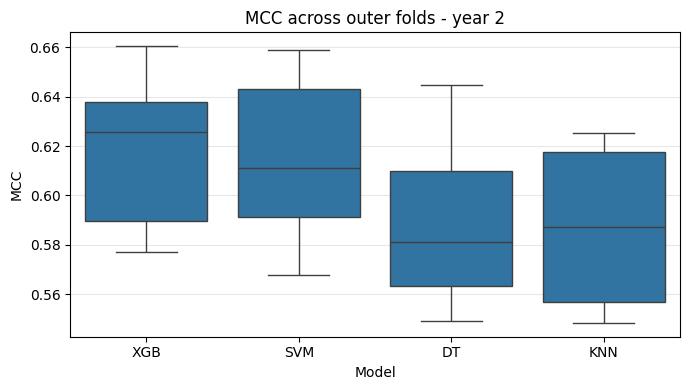

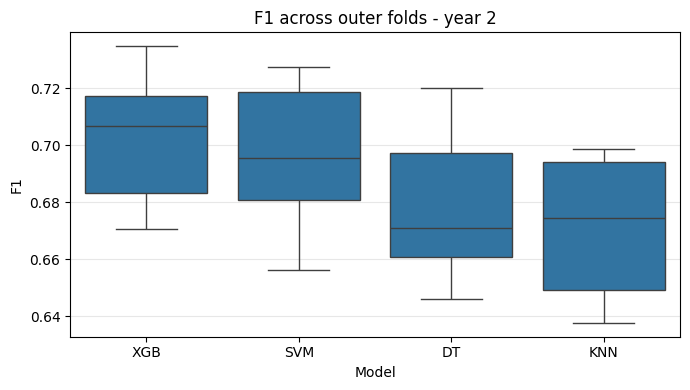

In [ ]:
for metric in metrics_list:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Model", y=metric)
    plt.title(f"{metric} across outer folds - year {year}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def summarize_with_ci(df_one_year, metric):
    rows = []
    for model, grp in df_one_year.groupby("Model"):
        vals = grp[metric].to_numpy()
        n = len(vals)
        mean = vals.mean()
        std  = vals.std(ddof=1)
        se   = std / np.sqrt(n)
        if n > 1:
            t_crit = t.ppf(0.975, df=n-1)  # 95% CI (two-sided)
            ci_low  = mean - t_crit * se
            ci_high = mean + t_crit * se
        else:
            ci_low, ci_high = np.nan, np.nan

        rows.append({
            "Model": model,
            "Metric": metric,
            "N_Folds": n,
            "Mean": mean,
            "Std": std,
            "CI95_Low": ci_low,
            "CI95_High": ci_high,
        })
    return pd.DataFrame(rows).sort_values("Model")



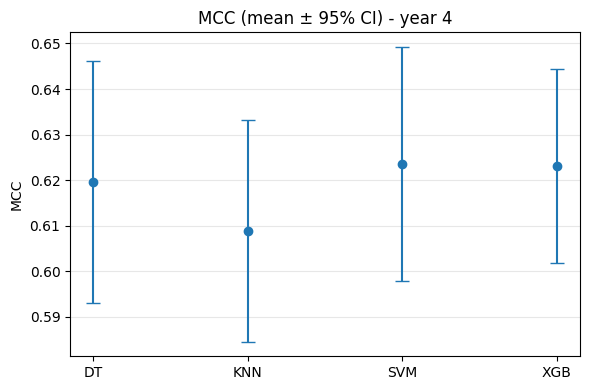

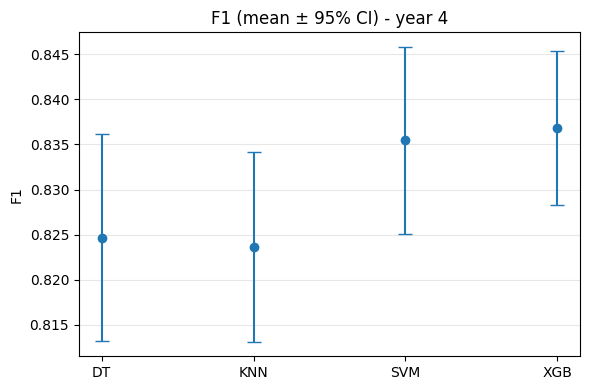

In [ ]:
metrics = ["MCC","F1"]
for metric in metrics_list:
    summary = summarize_with_ci(df, metric)
    x = np.arange(len(summary))
    means = summary["Mean"].values
    err_low = means - summary["CI95_Low"].values
    err_high = summary["CI95_High"].values - means
    plt.figure(figsize=(6,4))
    plt.errorbar(x, means, yerr=[err_low, err_high],
             fmt='o', capsize=5)
    plt.xticks(x, summary["Model"].values)
    plt.ylabel(metric)
    plt.title(f"{metric} (mean ± 95% CI) - year {year}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
all_ttests = []

for metric in metrics_list:
    scores = {
        m: df[df["Model"] == m].sort_values("Fold")[metric].to_numpy()
        for m in models
    }
    for a, b in combinations(models, 2):
        a_vals = scores[a]
        b_vals = scores[b]
        t_stat, p_val = ttest_rel(a_vals, b_vals)
        all_ttests.append({
            "Metric": metric,
            "Model_A": a,
            "Model_B": b,
            "t_stat": t_stat,
            "p_value": p_val,
        })

all_ttests_df = pd.DataFrame(all_ttests)
display(all_ttests_df)
all_ttests_df.to_csv(f"/content/gdrive/MyDrive/kidney_xgb_comparison/all_ttest_year{year}.csv", index=False)


,Metric,Model_A,Model_B,t_stat,p_value
0,MCC,DT,KNN,1.387123,0.198791
1,MCC,DT,SVM,-0.541772,0.601128
2,MCC,DT,XGB,-0.564457,0.586234
3,MCC,KNN,SVM,-1.864113,0.095188
4,MCC,KNN,XGB,-2.556124,0.030883
5,MCC,SVM,XGB,0.114655,0.911236
6,F1,DT,KNN,0.287061,0.780565
7,F1,DT,SVM,-3.627997,0.005503
8,F1,DT,XGB,-4.138563,0.002527
9,F1,KNN,SVM,-3.472600,0.007020


In [ ]:
def pairwise_wilcoxon(df, metric_col="MCC", model_col="Model", fold_col="Fold"):
    """
    Pairwise Wilcoxon signed-rank tests between models on a given metric.

    df must have columns:
        - model_col : model name (e.g. 'DT', 'KNN', 'SVM', 'XGB')
        - fold_col  : fold id (same folds for all models)
        - metric_col: metric value per model per fold (e.g. MCC or F1)
    """
    # pivot: rows = folds, cols = models, cells = metric
    wide = df.pivot(index=fold_col, columns=model_col, values=metric_col)

    results = []
    models = wide.columns.tolist()

    for m1, m2 in combinations(models, 2):
        x = wide[m1].values
        y = wide[m2].values

        # drop pairs with NaN
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean, y_clean = x[mask], y[mask]

        # differences
        diff = x_clean - y_clean

        # if all differences are (numerically) zero, Wilcoxon can't run
        if np.allclose(diff, 0):
            stat, p = 0.0, 1.0
        else:
            # two-sided Wilcoxon signed-rank
            stat, p = wilcoxon(x_clean, y_clean, alternative="two-sided")

        results.append({
            "Metric": metric_col,
            "Model_A": m1,
            "Model_B": m2,
            "n_pairs": len(x_clean),
            "w_stat": stat,
            "p_value": p
        })

    return pd.DataFrame(results)
wilc_all = pd.concat([
    pairwise_wilcoxon(df_metrics, metric_col="MCC"),
    pairwise_wilcoxon(df_metrics, metric_col="F1")
], ignore_index=True)

display(wilc_all)
wilc_all.to_csv(f"/content/gdrive/MyDrive/kidney_xgb_comparison/all_wilcoxon_year{year}.csv", index=False)


,Metric,Model_A,Model_B,n_pairs,w_stat,p_value
0,MCC,DT,KNN,10,17.0,0.322266
1,MCC,DT,SVM,10,22.0,0.625000
2,MCC,DT,XGB,10,21.0,0.556641
3,MCC,KNN,SVM,10,12.0,0.130859
4,MCC,KNN,XGB,10,8.0,0.048828
5,MCC,SVM,XGB,10,27.0,1.000000
6,F1,DT,KNN,10,22.0,0.625000
7,F1,DT,SVM,10,3.0,0.009766
8,F1,DT,XGB,10,0.0,0.001953
9,F1,KNN,SVM,10,5.0,0.019531
